# 04. SHAP Interpretation

## Goal

This notebook focuses on model interpretation rather than model selection.

The goal is not only to identify important features, but also to understand:

- which variables drive predictions globally,
- how feature values shift predictions up or down,
- and whether the interpretation is consistent with domain intuition.

I use `GradientBoostingRegressor` as the main predictive model, while keeping the strongest linear baseline from the previous notebook in mind as a reference point.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from model import get_models
from shap_utils import (
    build_shap_explainer,
    compute_shap_values,
    plot_shap_bar,
    plot_shap_beeswarm,
    get_mean_abs_shap,
    get_top_features
)

## Input Data

This notebook uses the processed training data generated in the feature engineering stage.

To keep the interpretation grounded, I first refit the selected nonlinear model on the processed training set, then apply SHAP to analyze the learned prediction structure.

In [2]:
train_processed = pd.read_csv("../data/processed/train_processed.csv")

X = train_processed.drop("SalePrice_log", axis=1)
y = train_processed["SalePrice_log"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1451, 275)
y shape: (1451,)


## Selected Model

Based on the previous model-comparison stage, I use `GradientBoostingRegressor` as the main nonlinear model for interpretation.

This choice is practical as well as conceptual: I want to interpret a model that is both reasonably strong and fully available in the current environment.

In [3]:
X = train_processed.drop("SalePrice_log", axis=1).copy()
y = train_processed["SalePrice_log"].copy()

print("Original dtype summary:")
print(X.dtypes.value_counts())

# Force all features to numeric
X = X.astype(float)

print("After astype(float):")
print(X.dtypes.value_counts())

print("Missing values:", X.isnull().sum().sum())

Original dtype summary:
bool       222
int64       36
float64     17
Name: count, dtype: int64
After astype(float):
float64    275
Name: count, dtype: int64
Missing values: 0


In [4]:
models = get_models(random_state=42)
gb_model = models["GradientBoosting"]
gb_model.fit(X, y)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",3000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thele

## Why SHAP?

SHAP provides an additive explanation framework for model predictions.

In this project, I use SHAP for two purposes:

1. **Global importance** — which features matter most overall?
2. **Directional interpretation** — when a feature takes a high or low value, does it push the predicted price upward or downward?

This is especially important because predictive performance alone does not tell us whether the model is relying on plausible housing-related signals.

In [15]:
X_sample = X.sample(n=min(500, len(X)), random_state=42)
import shap

explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_sample)

## 1. Global Feature Importance

I first inspect the mean absolute SHAP values to identify which features contribute most strongly to predictions across the dataset.

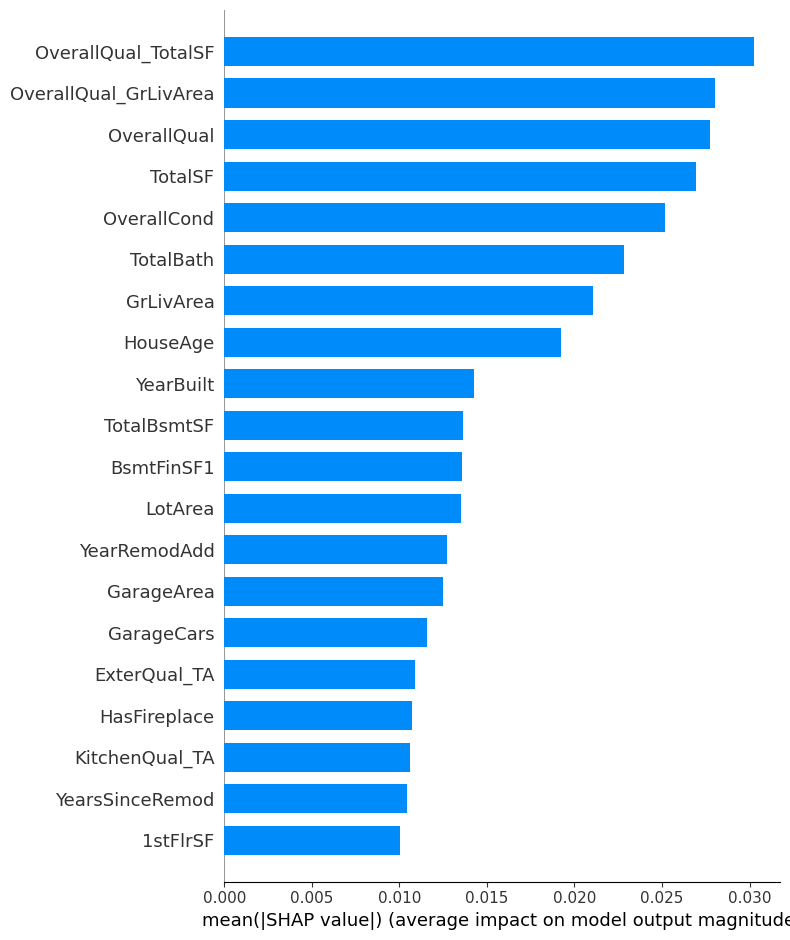

In [24]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.savefig("../results/figures/shap_bar_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. SHAP Beeswarm Plot

A bar chart shows importance magnitude, but it does not show direction.

The SHAP beeswarm plot helps answer a more refined question:

> When a feature is high or low, does it tend to push the prediction upward or downward?

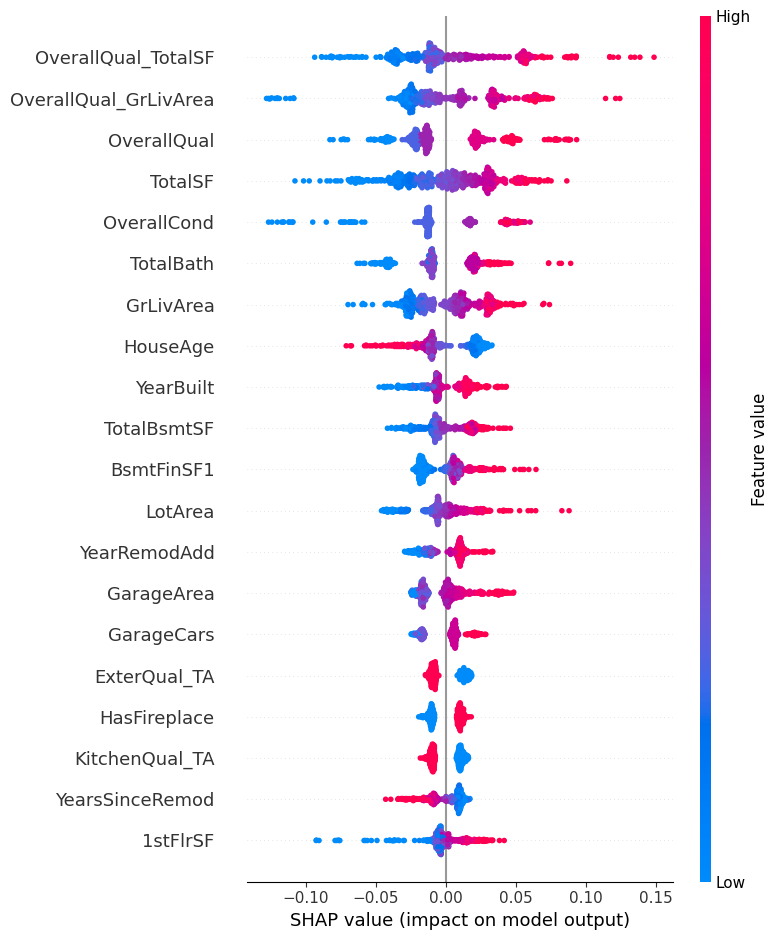

In [25]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig("../results/figures/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Top Features for Further Inspection

To make the interpretation more concrete, I extract the top features by mean absolute SHAP value.

In [27]:
import numpy as np
import pandas as pd

mean_abs = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": mean_abs
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_importance_df.head(20)
results_df = shap_importance_df.head(20)
results_df.to_csv("../results/tables/shap_importance.csv", index=False)

In [28]:
top_features = shap_importance_df["feature"].head(6).tolist()
top_features

['OverallQual_TotalSF',
 'OverallQual_GrLivArea',
 'OverallQual',
 'TotalSF',
 'OverallCond',
 'TotalBath']

SHAP dependence plot for: OverallQual_TotalSF
SHAP dependence plot for: OverallQual_GrLivArea
SHAP dependence plot for: OverallQual
SHAP dependence plot for: TotalSF
SHAP dependence plot for: OverallCond
SHAP dependence plot for: TotalBath


<Figure size 640x480 with 0 Axes>

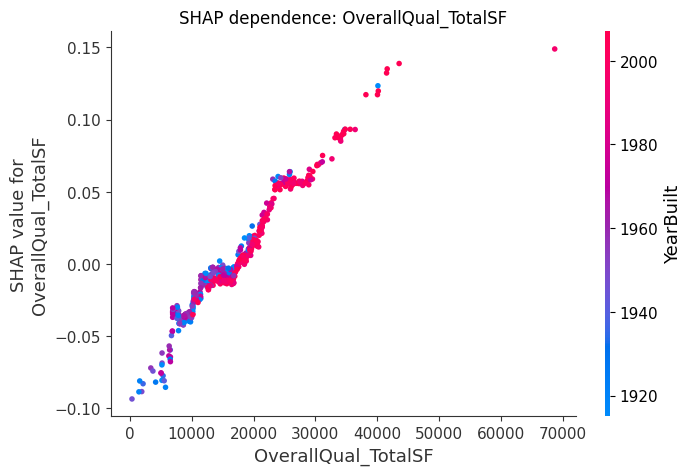

<Figure size 640x480 with 0 Axes>

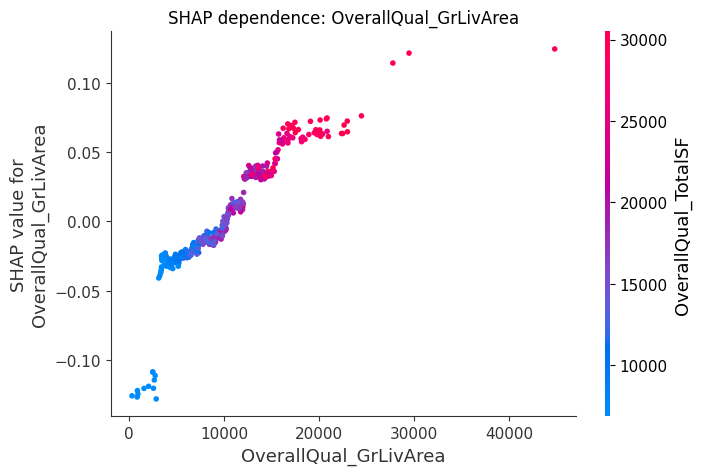

<Figure size 640x480 with 0 Axes>

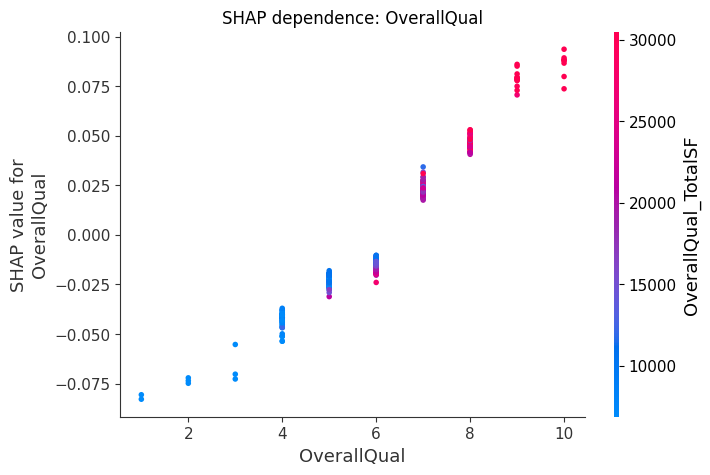

<Figure size 640x480 with 0 Axes>

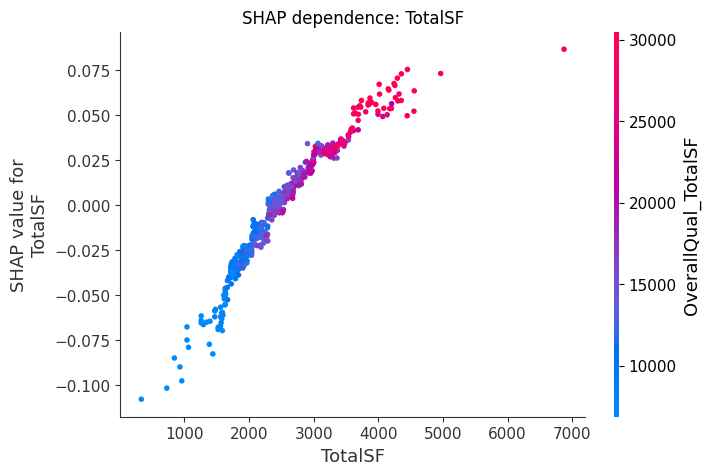

<Figure size 640x480 with 0 Axes>

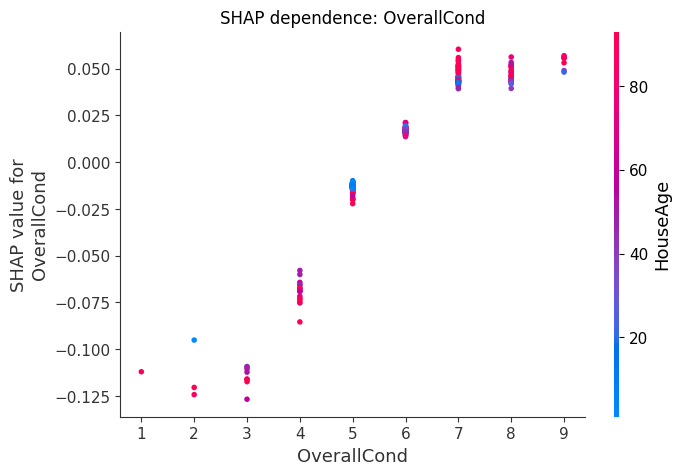

<Figure size 640x480 with 0 Axes>

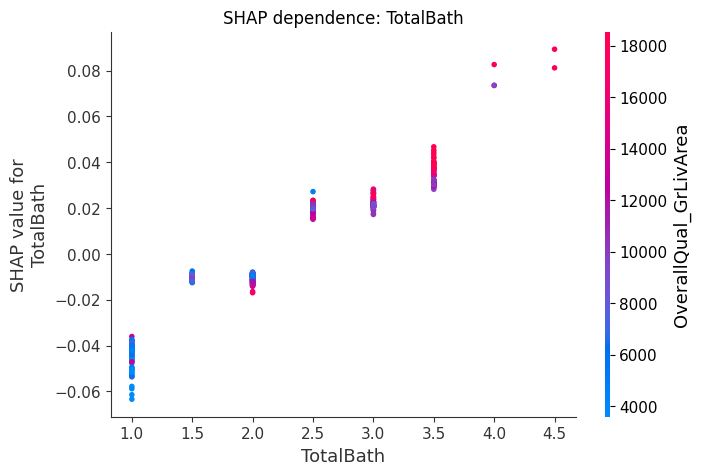

In [31]:
for feature in top_features:
    print(f"SHAP dependence plot for: {feature}")
    plt.figure()
    shap.dependence_plot(feature, shap_values, X_sample, interaction_index="auto", show = False)
    
    plt.title(f"SHAP dependence: {feature}")
    plt.savefig(
        f"../results/figures/shap_dependence_{feature}.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show

## 4. Linear Baseline as a Reference

As a reference point, I also inspect a regularized linear baseline. This is not the main interpretation tool here, but it helps contrast linear coefficient-based importance with SHAP-based importance from the selected nonlinear model.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

linear_ref = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.001, l1_ratio=0.9, random_state=42, max_iter=100000, tol=1e-3))
])

linear_ref.fit(X, y)

coef = linear_ref.named_steps["model"].coef_
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

coef_df.head(15)

,feature,coef,abs_coef
55,MSZoning_RL,0.074351,0.074351
23,TotRmsAbvGrd,0.065211,0.065211
52,AreaPerRoom,0.055875,0.055875
4,OverallQual,0.052697,0.052697
37,TotalSF,0.048434,0.048434
56,MSZoning_RM,0.047069,0.047069
40,HouseAge,-0.046527,0.046527
5,OverallCond,0.045172,0.045172
53,MSZoning_FV,0.040759,0.040759
267,SaleType_New,0.029731,0.029731


## Interpretation of SHAP Results

### 1. Global Structure of the Model

The SHAP importance ranking reveals a clear structural pattern in the model:

- Interaction features such as `OverallQual_TotalSF` and `OverallQual_GrLivArea` rank at the top.
- Core variables including `OverallQual`, `TotalSF`, and `GrLivArea` follow closely.
- Additional structural features such as `TotalBath`, `TotalBsmtSF`, and `GarageArea` also contribute significantly.

This suggests that the model does not rely on single variables in isolation, but instead captures **compositional effects between quality and space**.

In particular, the dominance of interaction features indicates that the model values houses that are both large and high-quality, rather than treating these two attributes independently.

### 2. Directional Effects and Economic Interpretation

From the SHAP beeswarm and dependence plots, several consistent patterns emerge:

- **Quality and size variables (OverallQual, TotalSF, GrLivArea)**  
  Higher values consistently push predictions upward, indicating that larger and higher-quality houses are associated with higher prices.

- **Interaction features (OverallQual_TotalSF, OverallQual_GrLivArea)**  
  These show strong monotonic positive relationships, confirming that the combined effect of quality and size is more influential than either dimension alone.

- **HouseAge**  
  Higher values tend to push predictions downward, suggesting that older houses are penalized unless compensated by other features.

- **YearBuilt and YearRemodAdd**  
  Higher values push predictions upward, indicating that newer or recently renovated properties are valued more highly.

- **Categorical quality indicators (ExterQual_TA, KitchenQual_TA)**  
  These features often contribute negatively when active, reflecting that "typical" or mid-tier quality levels may be less competitive compared to higher-quality categories.

Overall, the directional effects are consistent with standard real estate intuition, which increases confidence in the model’s learned structure.

### 3. Nonlinear and Interaction Effects

The dependence plots further reveal several important nonlinear patterns:

- The relationship between `OverallQual_TotalSF` and prediction is strongly monotonic but exhibits diminishing returns at higher values, suggesting a saturation effect for very large and high-quality houses.

- `OverallQual` shows a step-like structure rather than a continuous curve, reflecting its ordinal nature. This indicates that moving between quality levels (e.g., from 5 to 6) has discrete economic impact.

- `TotalSF` and `GrLivArea` display smooth nonlinear growth patterns, suggesting that the marginal contribution of additional space is not constant.

- Color gradients in the plots (e.g., interaction with `YearBuilt` or `TotalSF`) indicate that **secondary variables modulate primary effects**, confirming the presence of interaction structures captured by the model.

These patterns highlight the advantage of nonlinear models over linear baselines, as they are able to capture threshold effects and interactions that are difficult to represent linearly.

### 4. Summary

The SHAP analysis suggests that the model learns a coherent valuation mechanism based on:

- structural quality,
- usable space,
- age and renovation,
- and interaction effects between quality and size.

Importantly, the learned patterns align well with domain knowledge, which strengthens the interpretability and credibility of the model.

This step moves the project beyond predictive performance toward **interpretable and trustworthy modeling**, which is central to my broader interest in robust machine learning systems.

## Key Findings from SHAP

1. The model is primarily driven by interactions between quality and size rather than individual variables.

2. Structural housing attributes (quality, space, age) dominate prediction, indicating a coherent economic interpretation.

3. Nonlinear effects such as diminishing returns and discrete quality jumps are clearly captured, which would be difficult for linear models to represent.